<a href="https://colab.research.google.com/github/maayanmatsliah-tech/Creature-vs-Trash/blob/main/ocean_life_vs_trash.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
import random
from google.colab import drive

drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/datasets'
sea_source = os.path.join(base_path, 'sea_animals_extracted')
trash_source = os.path.join(base_path, 'trash')

splits = ['train', 'val']
categories = ['sea_animals', 'trash']

# Create the new folder structure
for s in splits:
    for c in categories:
        os.makedirs(os.path.join(base_path, s, c), exist_ok=True)

def split_data(source, category_name, train_size=0.8):
    # Only grab files that look like images
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    files = [f for f in os.listdir(source)
             if f.lower().endswith(valid_extensions)]

    random.shuffle(files)

    split_idx = int(len(files) * train_size)
    train_files = files[:split_idx]
    val_files = files[split_idx:]

    print(f"Moving {len(train_files)} to {category_name} train and {len(val_files)} to val...")

    for f in train_files:
        shutil.move(os.path.join(source, f), os.path.join(base_path, 'train', category_name, f))
    for f in val_files:
        shutil.move(os.path.join(source, f), os.path.join(base_path, 'val', category_name, f))

# Run it
split_data(sea_source, 'sea_animals')
split_data(trash_source, 'trash')

print("Folders reorganized successfully!")

Mounted at /content/drive
Moving 0 to sea_animals train and 0 to val...
Moving 0 to trash train and 0 to val...
Folders reorganized successfully!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import os

# This part makes sure that if you have a GPU (Graphics Card) enabled, the AI uses it.
# It makes training 10x faster!
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using {device} for training.")

Using cuda:0 for training.


In [ ]:
# These are the instructions for processing the images
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224), # Crops and zooms to help AI learn
        transforms.RandomHorizontalFlip(), # Flips image so AI learns 'left vs right' doesn't matter
        transforms.ToTensor(),             # Converts image to numbers
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standardizes colors
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [ ]:
data_dir = '/content/drive/MyDrive/datasets'

# This links your folders to the rules we made above
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}

# This feeds images to the AI in small bites (batches of 4)
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Success! I found these categories: {class_names}")
print(f"Total images to learn from: {dataset_sizes['train']}")
print(f"Total images for the final exam: {dataset_sizes['val']}")

Success! I found these categories: ['sea_animals', 'trash']
Total images to learn from: 16685
Total images for the final exam: 4172


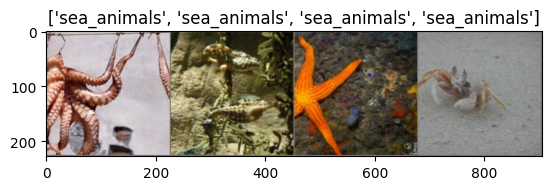

In [ ]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Get a batch of training data (4 images)
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [ ]:
# 1. Load the "expert" model
model_ft = models.resnet18(weights='IMAGENET1K_V1')

# 2. Find out how many 'features' the last layer handles
num_ftrs = model_ft.fc.in_features

# 3. Change the last layer to only output 2 categories
model_ft.fc = nn.Linear(num_ftrs, 2)

# 4. Send the model to your GPU (the fast processor)
model_ft = model_ft.to(device)

# 5. Define the "Grading System" (Loss Function) and "Study Method" (Optimizer)
criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# 6. Decay the learning rate (slow down studying as it gets smarter)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

print("Brain loaded and ready for school!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


Brain loaded and ready for school!


In [ ]:
import time
from tempfile import TemporaryDirectory

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')
        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [ ]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=10)

Epoch 0/9
----------
train Loss: 0.0722 Acc: 0.9760
val Loss: 0.0231 Acc: 0.9919

Epoch 1/9
----------
train Loss: 0.0477 Acc: 0.9850
val Loss: 0.0186 Acc: 0.9930

Epoch 2/9
----------
train Loss: 0.0293 Acc: 0.9896
val Loss: 0.0172 Acc: 0.9954

Epoch 3/9
----------
train Loss: 0.0266 Acc: 0.9909
val Loss: 0.0188 Acc: 0.9942

Epoch 4/9
----------
train Loss: 0.0176 Acc: 0.9938
val Loss: 0.0099 Acc: 0.9962

Epoch 5/9
----------
train Loss: 0.0197 Acc: 0.9931
val Loss: 0.0070 Acc: 0.9969

Epoch 6/9
----------
train Loss: 0.0199 Acc: 0.9942
val Loss: 0.0065 Acc: 0.9978

Epoch 7/9
----------
train Loss: 0.0077 Acc: 0.9977
val Loss: 0.0064 Acc: 0.9976

Epoch 8/9
----------
train Loss: 0.0068 Acc: 0.9980
val Loss: 0.0058 Acc: 0.9978

Epoch 9/9
----------
train Loss: 0.0087 Acc: 0.9975
val Loss: 0.0059 Acc: 0.9981

Training complete in 74m 22s
Best val Acc: 0.998082
